## sample

In [10]:
from pathlib import Path
import shutil, random

repair_src = Path("/data/project_backup/swc_fix/sk_lod1_783_healed_260609_fixed_classified_segment_cleaned_syn_type_visual_release/soma_pruned")
raw_src = Path("/data/project_backup/swc_fix/sk_lod1_783_healed_260609")
out = Path("/data/project_backup/swc_fix/sample2")
n, seed = 1000, 1

for d in [out/"repair", out/"raw"]:
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True)

files = list(repair_src.glob("*.swc"))
sampled = random.Random(seed).sample(files, n)
raw = {p.name: p for p in raw_src.rglob("*.swc")}

missing = []
for f in sampled:
    shutil.copy2(f, out/"repair"/f.name)
    if f.name in raw:
        shutil.copy2(raw[f.name], out/"raw"/f.name)
    else:
        missing.append(f.name)

print(f"Sampled: {len(sampled)}")
print(f"Raw copied: {len(sampled)-len(missing)}")
print(f"Missing raw: {len(missing)}")
if missing:
    print(*missing, sep="\n")

Sampled: 1000
Raw copied: 1000
Missing raw: 0


## mesh_math analysis

In [11]:
from flywire_swc_mesh_compare_batch import compare_swc_folder_to_online_mesh

summary = compare_swc_folder_to_online_mesh(
    swc_dir="/data/project_backup/swc_fix/sample2/repair",
    output_dir="/data/project_backup/swc_fix/sample2",
    xyz_unit="nm",
    radius_unit="nm",
    dataset="flat_783",
    surface_samples=80000,
    spacing_nm=250,
    max_samples_per_edge=128,
    exact_center_distance=True,
    random_seed=42,
    resume=True,
)

Total SWCs: 1,000
Already completed: 0
Pending: 1,000


Comparing SWCs with FlyWire meshes:   0%|          | 0/1000 [00:00<?, ?it/s]

Completed SWCs: 1,000
Summary: /data/project_backup/swc_fix/sample2/mesh_match_summary.csv


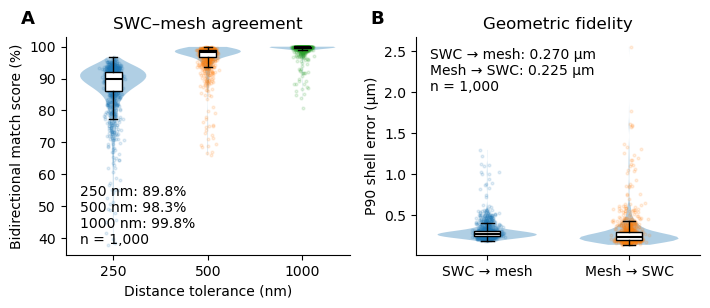

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path("/data/project_backup/swc_fix/sample2")
df = pd.read_csv(root/"mesh_match_summary_repair.csv")
df = df[df["scope"].eq("all")]
rng = np.random.default_rng(42)

fig, ax = plt.subplots(1, 2, figsize=(7.2, 3.2))

# A
ths = [250, 500, 1000]
data = [df[f"match_score_{t}nm"].dropna() for t in ths]

v = ax[0].violinplot(data, [1,2,3], widths=.7, showextrema=False)
for b in v["bodies"]: b.set_alpha(.35)

ax[0].boxplot(
    data, positions=[1,2,3], widths=.18, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=1.5)
)

for x,y in zip([1,2,3], data):
    ax[0].scatter(rng.normal(x,.04,len(y)), y, s=4, alpha=.12)

ax[0].set(
    xticks=[1,2,3], xticklabels=["250","500","1000"],
    xlabel="Distance tolerance (nm)",
    ylabel="Bidirectional match score (%)",
    title="SWC–mesh agreement"
)
ax[0].text(
    .05,.05,
    "\n".join(f"{t} nm: {x.median():.1f}%" for t,x in zip(ths,data)) +
    f"\nn = {len(df):,}",
    transform=ax[0].transAxes
)

# B
err = [
    df["center_shell_error_p90_nm"].dropna()/1000,
    df["surface_shell_error_p90_nm"].dropna()/1000
]

v = ax[1].violinplot(err, [1,2], widths=.7, showextrema=False)
for b in v["bodies"]: b.set_alpha(.35)

ax[1].boxplot(
    err, positions=[1,2], widths=.18, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=1.5)
)

for x,y in zip([1,2], err):
    ax[1].scatter(rng.normal(x,.04,len(y)), y, s=4, alpha=.12)

ax[1].set(
    xticks=[1,2], xticklabels=["SWC → mesh","Mesh → SWC"],
    ylabel="P90 shell error (μm)",
    title="Geometric fidelity"
)
ax[1].text(
    .05,.95,
    f"SWC → mesh: {np.median(err[0]):.3f} μm\n"
    f"Mesh → SWC: {np.median(err[1]):.3f} μm\n"
    f"n = {len(df):,}",
    transform=ax[1].transAxes, va="top"
)

for i,a in enumerate(ax):
    a.spines[["top","right"]].set_visible(False)
    a.text(-.16,1.06,chr(65+i),transform=a.transAxes,
           fontsize=13,fontweight="bold")

plt.tight_layout()
plt.savefig(root/"mesh_match_main_figure.pdf", bbox_inches="tight")
plt.savefig(root/"mesh_match_main_figure.png", dpi=600, bbox_inches="tight")
plt.show()

In [13]:
from flywire_swc_mesh_compare_batch import compare_swc_folder_to_online_mesh

summary = compare_swc_folder_to_online_mesh(
    swc_dir="/data/project_backup/swc_fix/sample2/raw",
    output_dir="/data/project_backup/swc_fix/sample2",
    xyz_unit="nm",
    radius_unit="nm",
    dataset="flat_783",
    surface_samples=80000,
    spacing_nm=250,
    max_samples_per_edge=128,
    exact_center_distance=True,
    random_seed=42,
    resume=True,
)

Total SWCs: 1,000
Already completed: 0
Pending: 1,000


Comparing SWCs with FlyWire meshes:   0%|          | 0/1000 [00:00<?, ?it/s]

Completed SWCs: 1,000
Summary: /data/project_backup/swc_fix/sample2/mesh_match_summary.csv


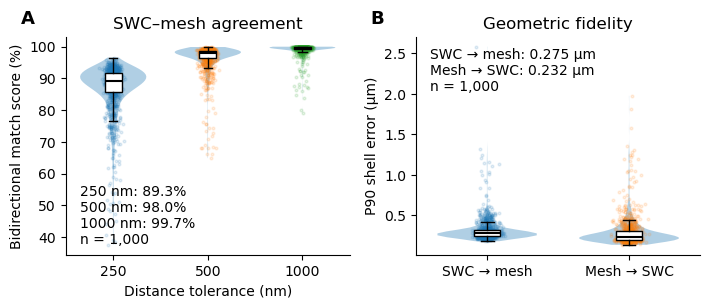

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path("/data/project_backup/swc_fix/sample2")
df = pd.read_csv(root/"mesh_match_summary_raw.csv")
df = df[df["scope"].eq("all")]
rng = np.random.default_rng(42)

fig, ax = plt.subplots(1, 2, figsize=(7.2, 3.2))

# A
ths = [250, 500, 1000]
data = [df[f"match_score_{t}nm"].dropna() for t in ths]

v = ax[0].violinplot(data, [1,2,3], widths=.7, showextrema=False)
for b in v["bodies"]: b.set_alpha(.35)

ax[0].boxplot(
    data, positions=[1,2,3], widths=.18, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=1.5)
)

for x,y in zip([1,2,3], data):
    ax[0].scatter(rng.normal(x,.04,len(y)), y, s=4, alpha=.12)

ax[0].set(
    xticks=[1,2,3], xticklabels=["250","500","1000"],
    xlabel="Distance tolerance (nm)",
    ylabel="Bidirectional match score (%)",
    title="SWC–mesh agreement"
)
ax[0].text(
    .05,.05,
    "\n".join(f"{t} nm: {x.median():.1f}%" for t,x in zip(ths,data)) +
    f"\nn = {len(df):,}",
    transform=ax[0].transAxes
)

# B
err = [
    df["center_shell_error_p90_nm"].dropna()/1000,
    df["surface_shell_error_p90_nm"].dropna()/1000
]

v = ax[1].violinplot(err, [1,2], widths=.7, showextrema=False)
for b in v["bodies"]: b.set_alpha(.35)

ax[1].boxplot(
    err, positions=[1,2], widths=.18, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=1.5)
)

for x,y in zip([1,2], err):
    ax[1].scatter(rng.normal(x,.04,len(y)), y, s=4, alpha=.12)

ax[1].set(
    xticks=[1,2], xticklabels=["SWC → mesh","Mesh → SWC"],
    ylabel="P90 shell error (μm)",
    title="Geometric fidelity"
)
ax[1].text(
    .05,.95,
    f"SWC → mesh: {np.median(err[0]):.3f} μm\n"
    f"Mesh → SWC: {np.median(err[1]):.3f} μm\n"
    f"n = {len(df):,}",
    transform=ax[1].transAxes, va="top"
)

for i,a in enumerate(ax):
    a.spines[["top","right"]].set_visible(False)
    a.text(-.16,1.06,chr(65+i),transform=a.transAxes,
           fontsize=13,fontweight="bold")

plt.tight_layout()
plt.savefig(root/"mesh_match_main_figure_raw.pdf", bbox_inches="tight")
plt.savefig(root/"mesh_match_main_figure_raw.png", dpi=600, bbox_inches="tight")
plt.show()

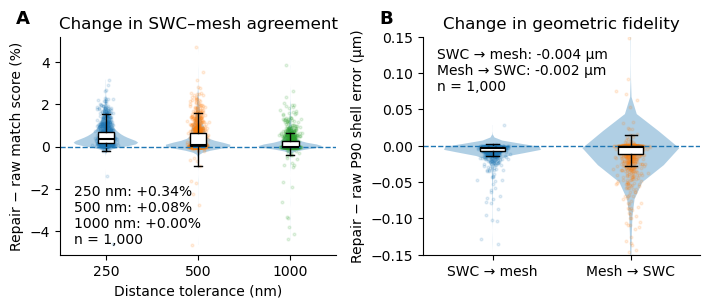

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path("/data/project_backup/swc_fix/sample1")
raw = pd.read_csv(root/"mesh_match_summary_raw.csv")
rep = pd.read_csv(root/"mesh_match_summary_repair.csv")

raw = raw[raw["scope"].eq("all")].copy()
rep = rep[rep["scope"].eq("all")].copy()

# 用 root_id 配对；如果你更想稳妥，也可以改成 Path(swc_file).name
raw["root_id"] = raw["root_id"].astype(str)
rep["root_id"] = rep["root_id"].astype(str)

keep = [
    "root_id",
    "match_score_250nm", "match_score_500nm", "match_score_1000nm",
    "center_shell_error_p90_nm", "surface_shell_error_p90_nm"
]

d = rep[keep].merge(raw[keep], on="root_id", suffixes=("_repair", "_raw"))

# delta: repair - raw
for t in [250, 500, 1000]:
    d[f"delta_match_{t}nm"] = d[f"match_score_{t}nm_repair"] - d[f"match_score_{t}nm_raw"]

d["delta_center_p90_um"]  = (d["center_shell_error_p90_nm_repair"]  - d["center_shell_error_p90_nm_raw"]) / 1000
d["delta_surface_p90_um"] = (d["surface_shell_error_p90_nm_repair"] - d["surface_shell_error_p90_nm_raw"]) / 1000

fig, ax = plt.subplots(1, 2, figsize=(7.2, 3.2))
rng = np.random.default_rng(42)

# A. change in match score
ths = [250, 500, 1000]
data = [d[f"delta_match_{t}nm"].dropna() for t in ths]
pos = [1, 2, 3]

v = ax[0].violinplot(data, pos, widths=.7, showextrema=False)
for b in v["bodies"]:
    b.set_alpha(.35)

ax[0].boxplot(
    data, positions=pos, widths=.18, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=1.5)
)

for x, y in zip(pos, data):
    ax[0].scatter(rng.normal(x, .04, len(y)), y, s=4, alpha=.12)

ax[0].axhline(0, ls="--", lw=1)
ax[0].set(
    xticks=pos,
    xticklabels=["250", "500", "1000"],
    xlabel="Distance tolerance (nm)",
    ylabel="Repair − raw match score (%)",
    title="Change in SWC–mesh agreement"
)
ax[0].text(
    .05, .05,
    "\n".join(f"{t} nm: {np.median(x):+.2f}%" for t, x in zip(ths, data)) +
    f"\nn = {len(d):,}",
    transform=ax[0].transAxes
)

# B. change in geometric error
err = [d["delta_center_p90_um"].dropna(), d["delta_surface_p90_um"].dropna()]
labels = ["SWC → mesh", "Mesh → SWC"]

v = ax[1].violinplot(err, [1, 2], widths=.7, showextrema=False)
for b in v["bodies"]:
    b.set_alpha(.35)

ax[1].boxplot(
    err, positions=[1, 2], widths=.18, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=1.5)
)

for x, y in zip([1, 2], err):
    ax[1].scatter(rng.normal(x, .04, len(y)), y, s=4, alpha=.12)

ax[1].axhline(0, ls="--", lw=1)
ax[1].set(
    xticks=[1, 2],
    xticklabels=labels,
    ylabel="Repair − raw P90 shell error (μm)",
    title="Change in geometric fidelity"
)

ax[1].set_ylim(-0.15, 0.15)

ax[1].text(
    .05, .95,
    f"SWC → mesh: {np.median(err[0]):+.3f} μm\n"
    f"Mesh → SWC: {np.median(err[1]):+.3f} μm\n"
    f"n = {len(d):,}",
    transform=ax[1].transAxes, va="top"
)

for i, a in enumerate(ax):
    a.spines[["top", "right"]].set_visible(False)
    a.text(-.16, 1.06, chr(65+i), transform=a.transAxes,
           fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(root/"mesh_raw_vs_repair_change.pdf", bbox_inches="tight")
plt.savefig(root/"mesh_raw_vs_repair_change.png", dpi=600, bbox_inches="tight")
plt.show()

## nblast

In [16]:
from swc_retrieval_compact import run_all

results = run_all(
    original_dir="/data/project_backup/swc_fix/sample2/raw",
    repaired_dir="/data/project_backup/swc_fix/sample2/repair",
    output_dir="/data/project_backup/swc_fix/sample2",
    resume=True,
    limit=None,
)

Building raw MinHash index:   0%|          | 0/1000 [00:00<?, ?it/s]

Indexed: 1,000


NBLAST:   0%|          | 0/1000 [00:00<?, ?it/s]

Completed: 1,000
Top-1 retention: 100.00%
Median paired NBLAST: 0.9915
Median delta NBLAST: 0.7476
Min hard negatives: 30


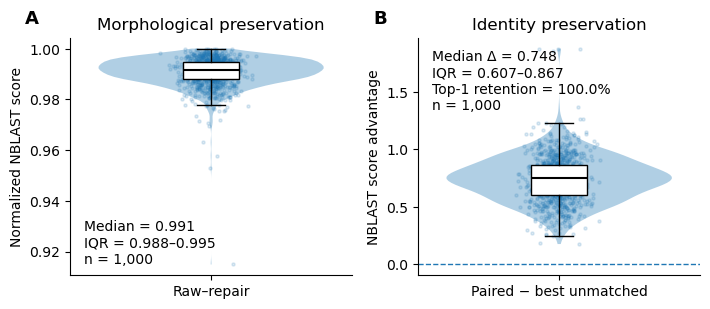

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path("/data/project_backup/swc_fix/sample2")
s = pd.read_csv(root/"nblast_summary_clean.csv")

to_bool = lambda x: x.astype(str).str.lower().eq("true")

paired = s["paired_nblast_score"].dropna()
delta = s["delta_nblast"].dropna()

acc = to_bool(s["top1_is_same_name"]).mean() * 100
med, (q1, q3) = paired.median(), paired.quantile([.25, .75])
med_delta, (dq1, dq3) = delta.median(), delta.quantile([.25, .75])

fig, ax = plt.subplots(1, 2, figsize=(7.2, 3.2))
rng = np.random.default_rng(42)

# A. Morphological preservation
v = ax[0].violinplot(paired, [1], widths=.72, showextrema=False)
for b in v["bodies"]: b.set_alpha(.35)

ax[0].boxplot(
    paired, positions=[1], widths=.18, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=1.5)
)
ax[0].scatter(rng.normal(1, .045, len(paired)), paired, s=5, alpha=.15)
ax[0].set(
    xlim=(.55, 1.45), xticks=[1], xticklabels=["Raw–repair"],
    ylabel="Normalized NBLAST score",
    title="Morphological preservation"
)
ax[0].text(
    .05, .05,
    f"Median = {med:.3f}\nIQR = {q1:.3f}–{q3:.3f}\nn = {len(paired):,}",
    transform=ax[0].transAxes
)

# B. Identity preservation
v = ax[1].violinplot(delta, [1], widths=.72, showextrema=False)
for b in v["bodies"]: b.set_alpha(.35)

ax[1].boxplot(
    delta, positions=[1], widths=.18, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=1.5)
)
ax[1].scatter(rng.normal(1, .045, len(delta)), delta, s=5, alpha=.15)
ax[1].axhline(0, ls="--", lw=1)

ax[1].set(
    xlim=(.55, 1.45), xticks=[1],
    xticklabels=["Paired − best unmatched"],
    ylabel="NBLAST score advantage",
    title="Identity preservation"
)
ax[1].text(
    .05, .95,
    f"Median Δ = {med_delta:.3f}\n"
    f"IQR = {dq1:.3f}–{dq3:.3f}\n"
    f"Top-1 retention = {acc:.1f}%\n"
    f"n = {len(delta):,}",
    transform=ax[1].transAxes, va="top"
)

for i, a in enumerate(ax):
    a.spines[["top", "right"]].set_visible(False)
    a.text(
        -.16, 1.06, chr(65+i),
        transform=a.transAxes,
        fontsize=13, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(root/"nblast_main_figure.pdf", bbox_inches="tight")
plt.savefig(root/"nblast_main_figure.png", dpi=600, bbox_inches="tight")
plt.show()